# k-Means Clustering

### Anthony Higareda

Here we will explore a class of unsupervised machine learning models: clustering algorithms.
Clustering algorithms seek to learn, from the properties of the data, an optimal division or discrete labeling of groups of points.

Many clustering algorithms are available in Scikit-Learn and elsewhere, but perhaps the simplest to understand is an algorithm known as *k-means clustering*, which is implemented in ``sklearn.cluster.KMeans``.

We begin with some imports:

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()  # for plot styling
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
import itertools
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score
from sklearn import preprocessing
from sklearn.decomposition import PCA

## Excercise 1: 
Import the Candy data and show the first 10 rows.  Write a dataset description based on the information provided.  

In [2]:
candy = pd.read_csv("candy-data.csv")
candy.head(10)

,competitorname,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent,pricepercent,winpercent
0,100 Grand,1,0,1,0,0,1,0,1,0,0.732,0.860,66.971725
1,3 Musketeers,1,0,0,0,1,0,0,1,0,0.604,0.511,67.602936
2,One dime,0,0,0,0,0,0,0,0,0,0.011,0.116,32.261086
3,One quarter,0,0,0,0,0,0,0,0,0,0.011,0.511,46.116505
4,Air Heads,0,1,0,0,0,0,0,0,0,0.906,0.511,52.341465
5,Almond Joy,1,0,0,1,0,0,0,1,0,0.465,0.767,50.347546
6,Baby Ruth,1,0,1,1,1,0,0,1,0,0.604,0.767,56.914547
7,Boston Baked Beans,0,0,0,1,0,0,0,0,1,0.313,0.511,23.417824
8,Candy Corn,0,0,0,0,0,0,0,0,1,0.906,0.325,38.010963
9,Caramel Apple Pops,0,1,1,0,0,0,0,0,0,0.604,0.325,34.517681


## Dataset Description
**This was taken from README.md in the github repo: https://github.com/fivethirtyeight/data/tree/master/candy-power-ranking**

`candy-data.csv` includes attributes for each candy along with its ranking. For binary variables, 1 means yes, 0 means no.

The data contains the following fields:
| Header | Description |
| ------ | ----------- |
| chocolate 	| Does it contain chocolate? |
| fruity 	| Is it fruit flavored? |
| caramel 	| Is there caramel in the candy? |
| peanutalmondy 	| Does it contain peanuts, peanut butter or almonds? |
| nougat 	| Does it contain nougat? |
| crispedricewafer 	| Does it contain crisped rice, wafers, or a cookie component? |
| hard 	| Is it a hard candy? |
| bar 	| Is it a candy bar? |
| pluribus 	| Is it one of many candies in a bag or box? |
| sugarpercent 	| The percentile of sugar it falls under within the data set. |
| pricepercent 	| The unit price percentile compared to the rest of the set. |
| winpercent 	| The overall win percentage according to 269,000 matchups. |

## Exercise 2:

Create a scatter plot comparing the price percent and win percent.  Write a few sentences in the reflection below that describes what you observe (are there any obvious groups?).  

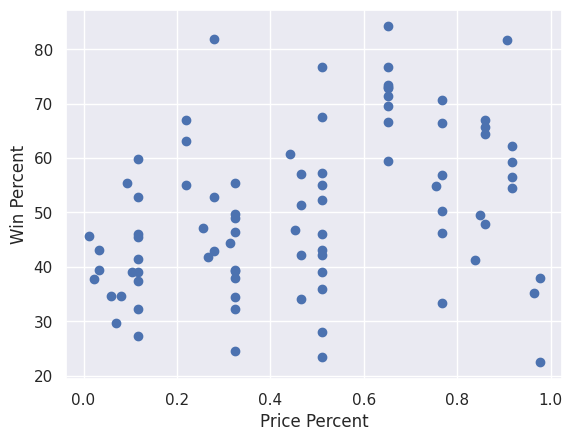

In [3]:
plt.scatter(x = candy["pricepercent"], y = candy["winpercent"])
plt.xlabel("Price Percent")
plt.ylabel("Win Percent")
plt.show()

### Reflection
The most obvious pattern I can see here is that the price percent seems to have specific "buckets" that each candy could fall in, which is creating the vertical line pattern when plotted against the win percentage. I can also see that the highest win percentage in each "price bucket" tends to increase as price increases, though there are quite a few exceptions. I can't see any obvious clusters that could be used for a classification because each "price bucket" has a large spread of win percentages.

## Exercise 3: 
In the following cell, convert the dataframe into a 2D numpy array called X that only contains numerical data (by dropping the one categorical column "competitorname" - this column does not contain relevant info for clustering). 

In [4]:
X = candy.drop('competitorname', axis = 1).to_numpy()
print(X)

[[1.0000000e+00 0.0000000e+00 1.0000000e+00 ... 7.3199999e-01
  8.6000001e-01 6.6971725e+01]
 [1.0000000e+00 0.0000000e+00 0.0000000e+00 ... 6.0399997e-01
  5.1099998e-01 6.7602936e+01]
 [0.0000000e+00 0.0000000e+00 0.0000000e+00 ... 1.1000000e-02
  1.1600000e-01 3.2261086e+01]
 ...
 [0.0000000e+00 1.0000000e+00 0.0000000e+00 ... 3.1299999e-01
  3.1299999e-01 4.4375519e+01]
 [0.0000000e+00 0.0000000e+00 1.0000000e+00 ... 1.8600000e-01
  2.6699999e-01 4.1904308e+01]
 [1.0000000e+00 0.0000000e+00 0.0000000e+00 ... 8.7199998e-01
  8.4799999e-01 4.9524113e+01]]


The following code will create a kMeans classifier using the data in ``X``.  Run this cell, and feel free to come back to experiment with different values of k.  You should not need to modify this cell if you completed the previous cell as expected.  

In [5]:
kmeans = KMeans(n_clusters=2)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

Let's visualize the results by plotting the data colored by these labels using the columns `pricepercent` and `winpercent`.
We will also plot the cluster centers in yellow as determined by the *k*-means estimator:

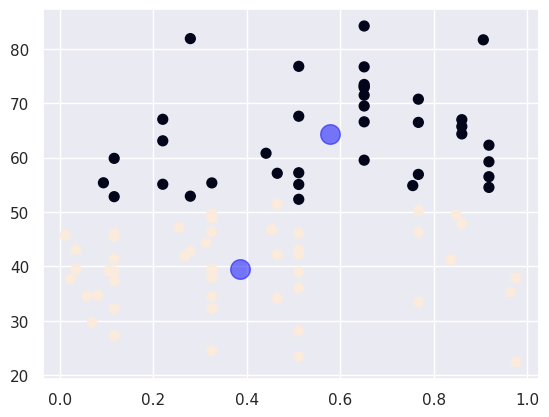

In [6]:
plt.scatter(X[:, 10], X[:, 11], c=y_kmeans, s=50)

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 10], centers[:, 11], c='blue', s=200, alpha=0.5)
plt.show()

## Exercise 4: 
This clustering isn't necessarily what you would expect, right?  This is most likely due to scaling bias in the distance calculation.  To address this, we need to scale the axes.  In the following cell, scale values using sklearn.preprocessing.scale(). You should re-do the clustering and plot the results to compare them to what you generated earlier. 

**Note: All further clustering should be done on the scaled data**

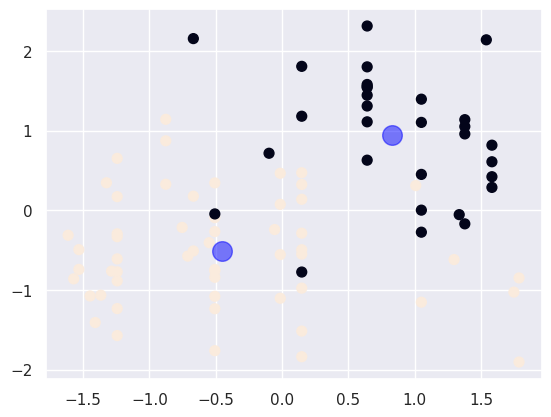

In [7]:
X_scaled = preprocessing.scale(X)

kmeans = KMeans(n_clusters=2)
kmeans.fit(X_scaled)
y_kmeans = kmeans.predict(X_scaled)

plt.scatter(X_scaled[:, 10], X_scaled[:, 11], c=y_kmeans, s=50)

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 10], centers[:, 11], c='blue', s=200, alpha=0.5)
plt.show()


### Reflection:

How do these results compare with your unscaled results?
Compared to the unscaled results, these seem to be classified with "low win, low price" and "high win, high price." There do appear to be a decent amount of overlap in the clusters, but it seems like a more reasonable split in the data as opposed to just splitting along the 50% win line.

## Exercise 5: 
Try (and display graphs of) three additional k values to see how KMeans clusters the data.  Additionally, apply Principal Components Analysis (PCA) to give a "good" view of your 11-dimensional data in 2 dimensions (see the unsupervised learning notebook from lecture for an exmample on how to do this).  Document your experiments and write a short description in the reflection section below - which set of k-means clusters appeared to give the most distinct separation between groups?

In [8]:
kmeans3 = KMeans(n_clusters=3)
kmeans3.fit(X_scaled)
y_kmeans3 = kmeans3.predict(X_scaled)

kmeans4 = KMeans(n_clusters=4)
kmeans4.fit(X_scaled)
y_kmeans4 = kmeans4.predict(X_scaled)

kmeans5 = KMeans(n_clusters=5)
kmeans5.fit(X_scaled)
y_kmeans5 = kmeans5.predict(X_scaled)


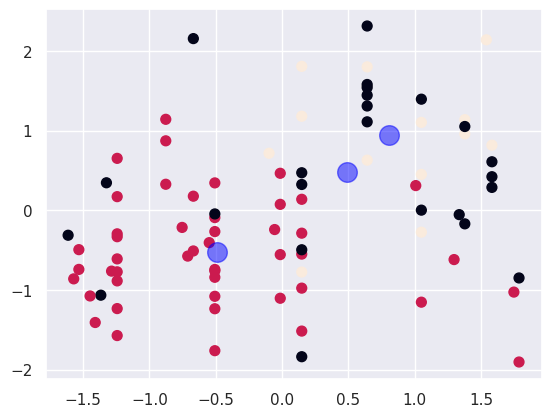

In [9]:
plt.scatter(X_scaled[:, 10], X_scaled[:, 11], c=y_kmeans3, s=50)

centers = kmeans3.cluster_centers_
plt.scatter(centers[:, 10], centers[:, 11], c='blue', s=200, alpha=0.5)
plt.show()

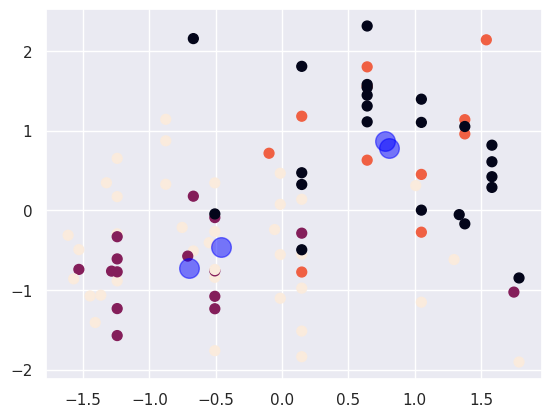

In [10]:
plt.scatter(X_scaled[:, 10], X_scaled[:, 11], c=y_kmeans4, s=50)

centers = kmeans4.cluster_centers_
plt.scatter(centers[:, 10], centers[:, 11], c='blue', s=200, alpha=0.5)
plt.show()

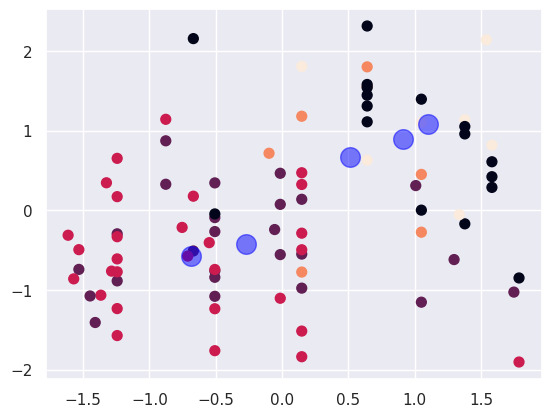

In [11]:
plt.scatter(X_scaled[:, 10], X_scaled[:, 11], c=y_kmeans5, s=50)

centers = kmeans5.cluster_centers_
plt.scatter(centers[:, 10], centers[:, 11], c='blue', s=200, alpha=0.5)
plt.show()

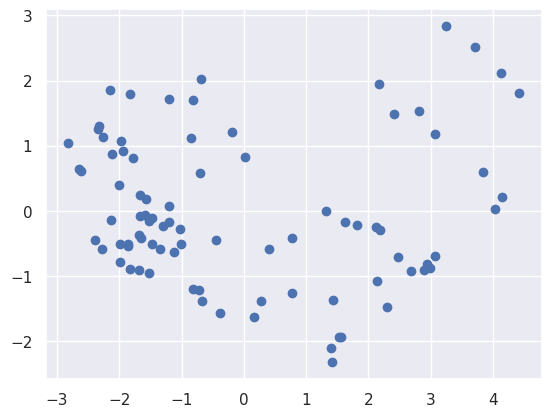

In [12]:
pca = PCA(n_components = 2)
X_reduced = pca.fit_transform(X_scaled)
plt.scatter(x = X_reduced[:,0], y = X_reduced[:,1])
plt.show()

### Reflection
I created sets with 3, 4, and 5 clusters. None of the K-Means clusters with more than 2 clusters had a clear separation of the groups. There was a lot of extra mess, and I cannot see any reasonable distinction between them.

## Excercise 6:

One way discussed in class to evaluate how "good" one group of clusters is is to compare the Davies-Bouldin score. Compute and display the Davies-Bouldin score for the 4 values of 'k' that you used above. Be sure to clearly label which output values belong to which graphs. 

Does the 'k' that the Davies Bouldin score denotes as creating the best clusters align with your "eye-balled" analysis from Exercise 5? If not, why might this be?

In [13]:
from sklearn import metrics

print("2 clusters " + str(metrics.davies_bouldin_score(X_scaled, kmeans.labels_)))
print("3 clusters " + str(metrics.davies_bouldin_score(X_scaled, kmeans3.labels_)))
print("4 clusters " + str(metrics.davies_bouldin_score(X_scaled, kmeans4.labels_)))
print("5 clusters " + str(metrics.davies_bouldin_score(X_scaled, kmeans5.labels_)))

2 clusters 1.4687066801954702
3 clusters 1.7260955788924635
4 clusters 1.9211836673046863
5 clusters 1.5334739488798528


### Reflection

The DB scores kind of align with my eyeballed analysis. 2 clusters does have the lowest value, but all of them are quite high. I was surprised at how close 5 clusters scored to 2 clusters, because I didn't see a distinct separation between the clusters.

## Exercise 7

Another way to evaluate which number of clusters is best is to use the "within cluster sum of squares" or inertia.  It is a measure of how coherent the clusters are.  We can look at a variety of k-values to see how the inertia changes for different k-values.  This is not a perfect measure (it is subject to several types of biases), but it can be used to compare different k-values.  

To use the "Elbow Method" you want to find an "elbow" where there is a distinct change in the plot of different k-values.  It is not always very obvious, but this describes what to look for: https://www.geeksforgeeks.org/elbow-method-for-optimal-value-of-k-in-kmeans/ 

Calculate the "inertia" for k-means clusters with k varying between 2 and 6 and display and "elbow plot". Using the "elbow" method, which number of clusters would you say is best? Why? (put answer in reflection below).

Note that for each clustering object you create, it has an attribute called "inertia_" that represents this value. 

Distortion values:
2 : 8.385389976844227
3 : 7.3666420213169514
4 : 6.568509075811499
5 : 5.60050383476437
6 : 5.122690085922422


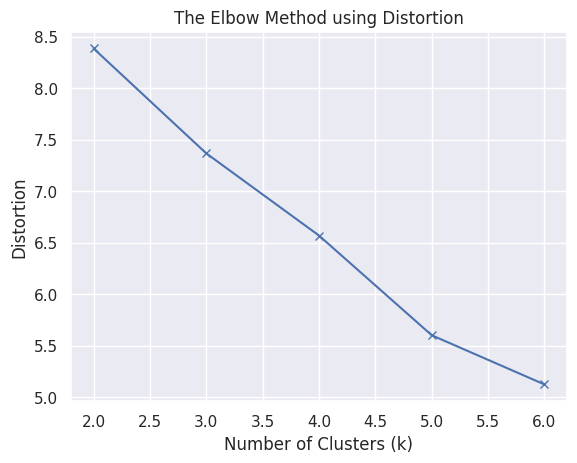

Inertia values:
2 : 712.758148031759
3 : 626.1645718119406
4 : 558.3232714439774
5 : 476.04282595497136
6 : 435.4286573034058


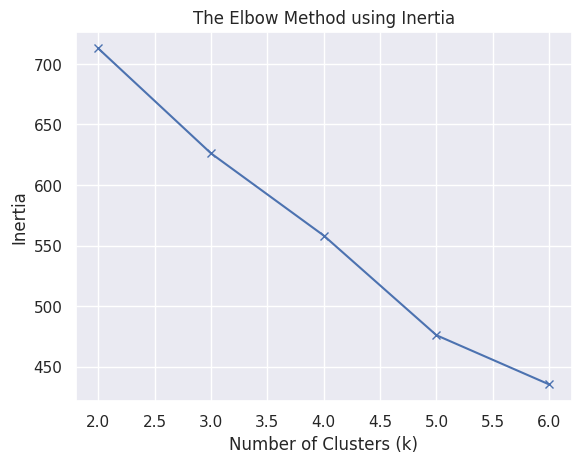

In [14]:
from scipy.spatial.distance import cdist

distortions = []
inertias = []
mapping1 = {}
mapping2 = {}
K = range(2, 7)

for k in K:
    kmeanModel = KMeans(n_clusters=k, random_state=42).fit(X_scaled)

    distortions.append(sum(np.min(cdist(X_scaled, kmeanModel.cluster_centers_, 'euclidean'), axis=1)**2) / X_scaled.shape[0])

    inertias.append(kmeanModel.inertia_)

    mapping1[k] = distortions[-1]
    mapping2[k] = inertias[-1]

print("Distortion values:")
for key, val in mapping1.items():
    print(f'{key} : {val}')

plt.plot(K, distortions, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Distortion')
plt.title('The Elbow Method using Distortion')
plt.show()

print("Inertia values:")
for key, val in mapping2.items():
    print(f'{key} : {val}')

plt.plot(K, inertias, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('The Elbow Method using Inertia')
plt.show()

## Reflection
According to the Inertia graph, It looks like 6 clusters should be the best because it has the lowest inertia score.

## Exercise 8

A third metric used to help identify how many clusters you should have is called the Silhouette Coefficient. You can read up on it in the following locations: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html and https://towardsdatascience.com/silhouette-coefficient-validating-clustering-techniques-e976bb81d10c.

Calculate and display the Silhouette Coefficient for k-means clusters with k varying between 2 and 6. Which k-value does the Silhouette Coefficient claim creates the best clusters?

**Answer here:**
The Silhouette Coefficient claims that 3 clusters is best because it has the value closest to 1

In [15]:
from sklearn.datasets import make_blobs

for k in K:
    X_data, y = make_blobs(random_state=42)

    kmeans = KMeans(n_clusters=k, random_state=42)

    print(str(k) + " clusters " +str(silhouette_score(X_data, kmeans.fit_predict(X_data))))

2 clusters 0.496137786540463
3 clusters 0.8469881221532085
4 clusters 0.6586325419766833
5 clusters 0.4982243808040681
6 clusters 0.3404198152365439


# Example: k-means on images

To start, let's take a look at applying *k*-means on simple handwritten digits images.  Here we will attempt to use *k*-means to try to identify similar digits *without using the original label information*.  We will start by loading the digits and then finding the ``KMeans`` clusters.

The digits data consist of 1,797 samples with 64 features, where each of the 64 features is the brightness of one pixel in an 8×8 image.  We start by loading the data

In [16]:
from sklearn.datasets import load_digits
digits = load_digits()

Let's take a look at one of the images.  

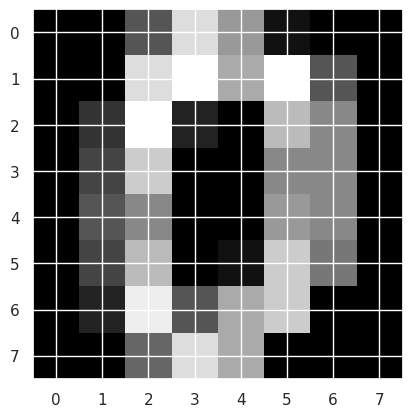

In [17]:
plt.imshow(digits.images[0], cmap='gray')
plt.show()

## Exercise 9:
Write a few lines of code to create a KMeans model using ``digits.data`` and 10 clusters.  No need to plot, just create the clusters for now. Note that you should name your model object `kmeans` and the assigned clusters to `clusters` so that the following code cells will run appropriately.

In [18]:
kmeans = KMeans(n_clusters=10)
kmeans.fit_transform(digits.data)
clusters = kmeans.predict(digits.data)

Let's see what the cluster centers look like:

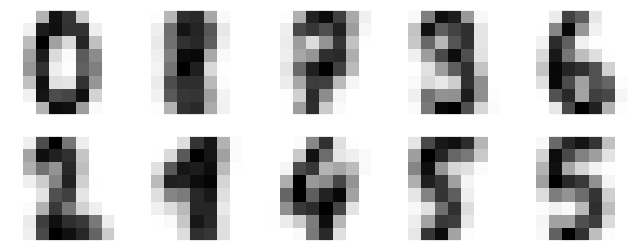

In [19]:
fig, ax = plt.subplots(2, 5, figsize=(8, 3))
centers = kmeans.cluster_centers_.reshape(10, 8, 8)
for axi, center in zip(ax.flat, centers):
    axi.set(xticks=[], yticks=[])
    axi.imshow(center, interpolation='nearest', cmap=plt.cm.binary)

We see that *even without the labels*, ``KMeans`` is able to cluster whose centers are recognizable digits, with the exception of 1 and 8.  

*k*-means knows nothing about the identity of the cluster, so the clusters are not in any specific order.  To identify the actual order, we can use the labels in the following code.  

In [20]:
from scipy.stats import mode

labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i) #array of booleans for each cluster group
    labels[mask] = mode(digits.target[mask])[0] #get "mode" of each cluster group's label

Now we can check how accurate our unsupervised clustering was in finding similar digits within the data:

In [21]:
from sklearn.metrics import accuracy_score
accuracy_score(digits.target, labels)

0.7406789092932665

With just a simple *k*-means algorithm, we discovered the correct grouping for 80% of the input digits!
Let's check the confusion matrix for this:

Text(109.44999999999997, 0.5, 'predicted label')

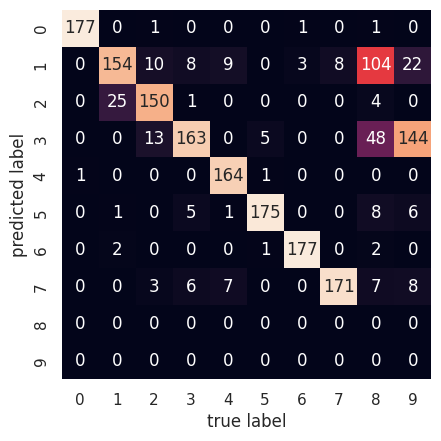

In [22]:
from sklearn.metrics import confusion_matrix
mat = confusion_matrix(digits.target, labels)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=digits.target_names,
            yticklabels=digits.target_names)
plt.xlabel('true label')
plt.ylabel('predicted label')

As we might expect from the cluster centers we visualized before, the main point of confusion is between the eights and ones.
But this still shows that using *k*-means, we can essentially build a digit classifier *without reference to any known labels*!

## Exercise 10:
Let's try this with higher resolution images!  Use the code below to import the 28x28 DIGITS images. Note, you will either need to be on Rosie's Tensorflow 2.x container, or you will likely need to install some libraries locally.

Then complete the following steps:
1. Plot an example image 
2. Train a KMeans cluster using the testing data.  Note that you will need to reshape the data to be in the correct format. Note that the N images will result in an N x 28 x 28 array. You will need to reshape the data to be an N x (28\*28) array. Look into the numpy .reshape() method to accomplish this.
3. Plot the cluster centers
4. Calculate the accuracy
5. Plot the confusion matrix
6. Use the training data and re-run the experiment to see how sensitive the model is to the data.  
7. Write a short reflection on what you observed from this and why it might be the case.  

In [31]:
import tensorflow as tf
from tensorflow import keras
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

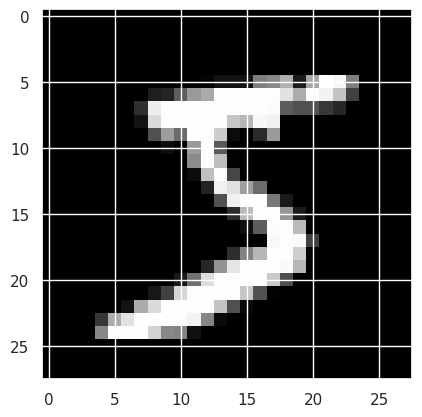

In [24]:
plt.imshow(X_train[0], cmap = 'gray')

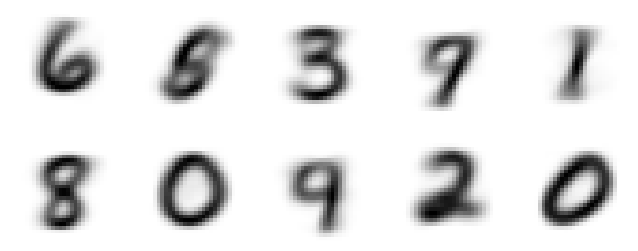

In [25]:
N = len(X_test)
X_test = X_test.reshape(N, 28 * 28)

kmeans = KMeans(n_clusters = 10)
kmeans.fit(X_test)
clusters = kmeans.predict(X_test)

fig, ax = plt.subplots(2, 5, figsize=(8, 3))
centers = kmeans.cluster_centers_.reshape(10, 28, 28)
for axi, center in zip(ax.flat, centers):
    axi.set(xticks=[], yticks=[])
    axi.imshow(center, interpolation='nearest', cmap=plt.cm.binary)

In [26]:
labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i) #array of booleans for each cluster group
    labels[mask] = mode(y_test[mask])[0] #get "mode" of each cluster group's label

accuracy_score(y_test, labels)

0.615

Text(109.44999999999997, 0.5, 'predicted label')

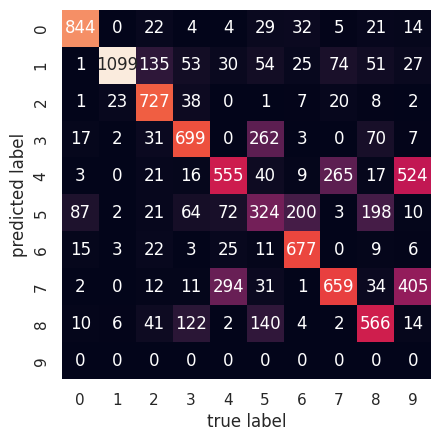

In [27]:
mat = confusion_matrix(y_test, labels)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=digits.target_names,
            yticklabels=digits.target_names)
plt.xlabel('true label')
plt.ylabel('predicted label')

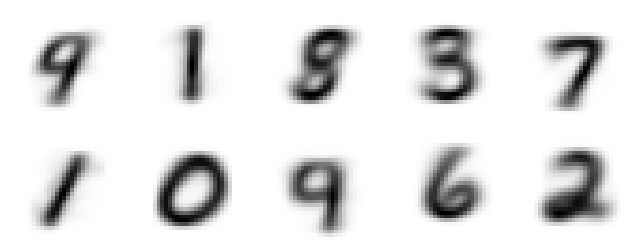

In [28]:
N = len(X_train)
X_train = X_train.reshape(N, 28 * 28)

kmeans = KMeans(n_clusters = 10)
kmeans.fit(X_train)
clusters = kmeans.predict(X_train)

fig, ax = plt.subplots(2, 5, figsize=(8, 3))
centers = kmeans.cluster_centers_.reshape(10, 28, 28)
for axi, center in zip(ax.flat, centers):
    axi.set(xticks=[], yticks=[])
    axi.imshow(center, interpolation='nearest', cmap=plt.cm.binary)

In [29]:
labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i) #array of booleans for each cluster group
    labels[mask] = mode(y_train[mask])[0] #get "mode" of each cluster group's label

accuracy_score(y_train, labels)

0.61715

Text(109.44999999999997, 0.5, 'predicted label')

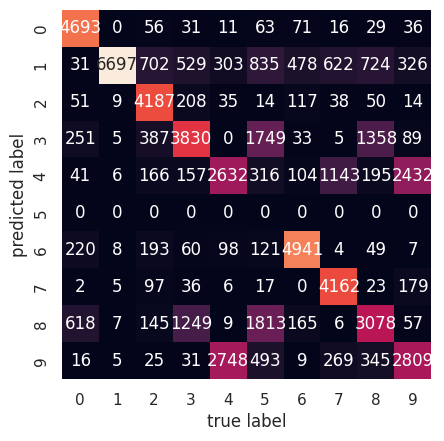

In [30]:
mat = confusion_matrix(y_train, labels)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=digits.target_names,
            yticklabels=digits.target_names)
plt.xlabel('true label')
plt.ylabel('predicted label')

### Reflection
I have observed that the model is marginally more accurate with the training data (61.7%) than with the testing data (61.5%), though the confusion matrix appears to contradict that. The line of true positive for the training data is much worse with respect to the testing data split. Additionally, the digit 5 was not predicted once with the training data, and the digit 1 was predicted quite frequently on the training data but was incorrect for a significant portion of the predictions. I could reason that the training data set would have a higher accuracy score because there is more data for the model to learn from and identify common patterns, but I'm not sure why the confusion matrices seem to differ so much.